# Channel Selection for Multivariate Time Series + I-ROCKET

This notebook demonstrates how to preprocess multivariate time series
data using channel selection before applying I-ROCKET for classification
and interpretation.

Many real-world signals are multivariate: neural recordings have
multiple electrodes, motion capture has multiple joints, EEG has
multiple scalp channels. Not all channels carry discriminative
information. Channel selection identifies which channels matter,
reducing computation and potentially improving accuracy.

The workflow:
1. **Channel selection** -- rank channels by class separability
2. **Flatten** -- concatenate selected channels into a univariate series
3. **I-ROCKET** -- classify and interpret the flattened representation
4. **Map back** -- relate I-ROCKET's temporal features to original channels

Reference:
  Dhariyal, B., Le Nguyen, T., and Ifrim, G. (2023).
  Scalable classifier-agnostic channel selection for multivariate
  time series classification. DMKD, 37:1010-1054.

In [1]:
# Suppress OpenMP diagnostic messages that numba triggers on startup.
# These are informational only and do not affect results.
import os
os.environ["OMP_DISPLAY_ENV"] = "FALSE"
os.environ["KMP_WARNINGS"] = "0"

import numpy as np
import matplotlib.pyplot as plt

RANDOM_STATE = 42

## 1. Generate synthetic multivariate data

We simulate an 8-channel recording where:
- Channels 1 and 4 contain class-discriminative signals (Gaussian
  bumps at different positions per class)
- The remaining 6 channels contain only noise

This mimics a neural recording where most electrodes are
uninformative and only a few capture the relevant signal.

In [2]:
def generate_multivariate_data(n_samples=200, n_channels=8,
                                n_timepoints=128,
                                informative_channels=(1, 4),
                                random_state=42):
    """
    Generate synthetic multivariate time series with known informative channels.

    Parameters
    ----------
    n_samples : int
    n_channels : int
    n_timepoints : int
    informative_channels : tuple of int
        Which channels contain class-discriminative signals.
    random_state : int

    Returns
    -------
    X : ndarray, shape (n_samples, n_channels, n_timepoints)
    y : ndarray, shape (n_samples,)
    """
    rng = np.random.RandomState(random_state)
    n_classes = 3
    n_samples = (n_samples // n_classes) * n_classes
    samples_per_class = n_samples // n_classes

    X = rng.normal(0, 0.5, (n_samples, n_channels, n_timepoints)).astype(np.float32)
    y = np.repeat(np.arange(n_classes), samples_per_class)[:n_samples]

    t = np.arange(n_timepoints, dtype=np.float32)
    bump_centers = {
        0: [0.25, 0.30],
        1: [0.50, 0.55],
        2: [0.75, 0.70],
    }

    for i in range(n_samples):
        cls = y[i]
        for j, ch in enumerate(informative_channels):
            center = int(bump_centers[cls][j] * n_timepoints)
            bump = 3.0 * np.exp(-0.5 * ((t - center) / 6.0) ** 2)
            X[i, ch, :] += bump

    rng.shuffle(np.arange(n_samples))  # shuffle order
    perm = rng.permutation(n_samples)
    X = X[perm]
    y = y[perm]

    return X, y

X_train, y_train = generate_multivariate_data(
    n_samples=300, random_state=RANDOM_STATE
)
X_test, y_test = generate_multivariate_data(
    n_samples=150, random_state=RANDOM_STATE + 1
)

print(f"Training data: {X_train.shape} (samples x channels x timepoints)")
print(f"Test data:     {X_test.shape}")
print(f"Classes: {np.unique(y_train)}")
print(f"Informative channels: 1, 4 (ground truth)")

Training data: (300, 8, 128) (samples x channels x timepoints)
Test data:     (150, 8, 128)
Classes: [0 1 2]
Informative channels: 1, 4 (ground truth)


In [3]:
whos ndarray

Variable   Type       Data/Info
-------------------------------
X_test     ndarray    150x8x128: 153600 elems, type `float32`, 614400 bytes (600.0 kb)
X_train    ndarray    300x8x128: 307200 elems, type `float32`, 1228800 bytes (1.171875 Mb)
y_test     ndarray    150: 150 elems, type `int64`, 1200 bytes
y_train    ndarray    300: 300 elems, type `int64`, 2400 bytes


## 2. Channel selection

The ECP (Elbow Class Pairwise) method computes the mean time series
per class for each channel, measures pairwise Euclidean distances
between class prototypes, and uses an elbow criterion to select
the most discriminative channels.

In [4]:
from channel_selection import (
    select_channels,
    flatten_channels,
    plot_channel_scores,
    plot_channel_prototypes,
)

selected, scores = select_channels(X_train, y_train, method='ecp')
print(f"\nSelected channels: {sorted(selected)}")
print(f"Ground truth informative: [1, 4]")

Channel selection (ECP, euclidean):
  8 channels, 3 selected (38%)
  Score range: [2.28, 41.73]
  Elbow at rank 2, threshold score = 2.52

Selected channels: [np.int64(1), np.int64(4), np.int64(5)]
Ground truth informative: [1, 4]


## 3. Visualize channel scores

The bar chart shows each channel's prototype distance score.
Channels 1 and 4 should stand out clearly above the noise channels.

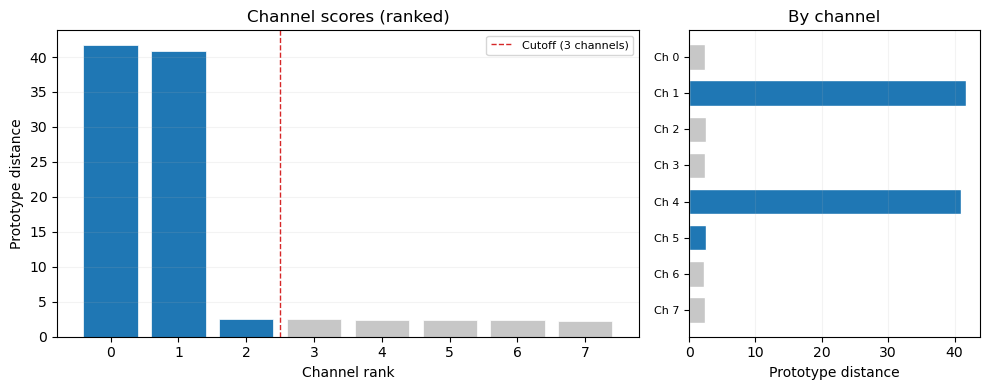

In [5]:
fig = plot_channel_scores(scores, selected=selected)

## 4. Visualize class prototypes per channel

For informative channels, the class prototypes (mean time series)
are visibly different. For noise channels, they overlap.

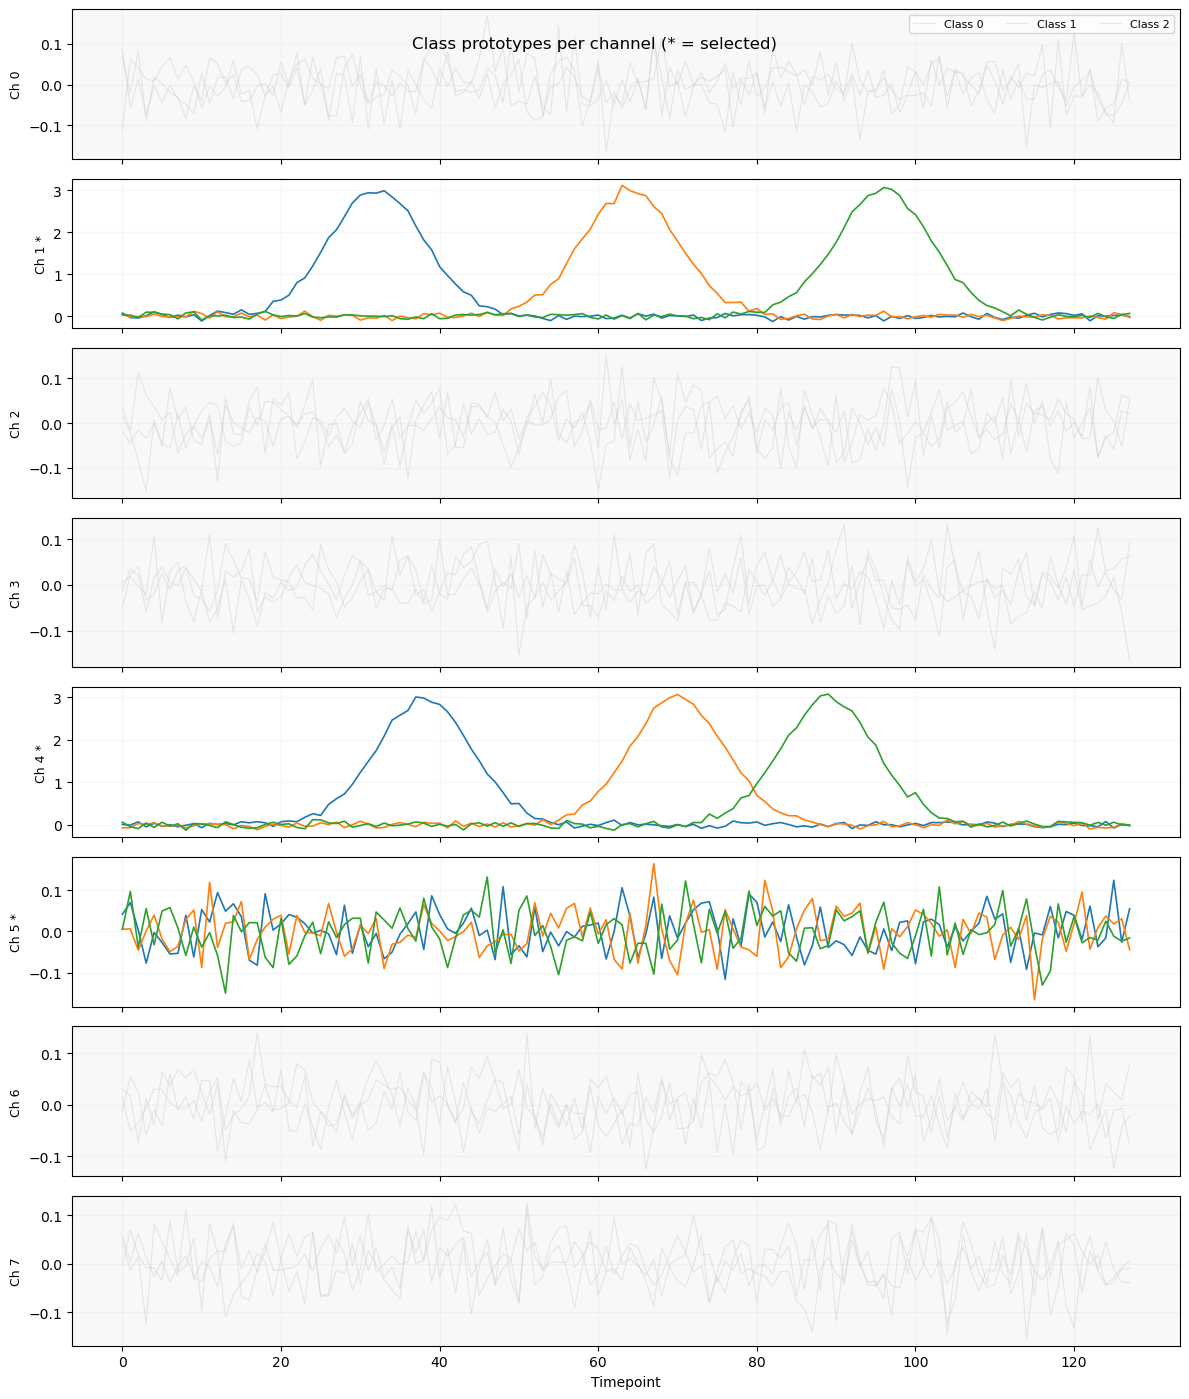

In [6]:
fig = plot_channel_prototypes(X_train, y_train, selected=selected)

## 5. Flatten and classify with I-ROCKET

After channel selection, we concatenate the selected channels
into a single long univariate time series and apply I-ROCKET.

We compare three approaches:
- All channels (no selection)
- Selected channels only (ECP)
- Ground truth channels only (oracle)

In [7]:
import interp_rocket as IR

results = {}

configs = {
    "All channels (8)": None,
    "ECP selected": selected,
    "Oracle (ch 1,4)": np.array([1, 4]),
}

for name, channels in configs.items():
    X_tr = flatten_channels(X_train, channels)
    X_te = flatten_channels(X_test, channels)

    model = IR.InterpRocket(max_dilations_per_kernel=16, random_state=RANDOM_STATE)
    model.fit(X_tr, y_train)
    metrics = model.evaluate(X_te, y_test)

    n_ch = len(channels) if channels is not None else X_train.shape[1]
    results[name] = {
        'accuracy': metrics['accuracy'],
        'n_channels': n_ch,
        'n_features': X_tr.shape[1],
    }
    print(f"{name}: acc={metrics['accuracy']:.4f}, "
          f"channels={n_ch}, features={X_tr.shape[1]}")

InterpRocket.fit: 300 instances × 1024 timepoints
  Classes: [0 1 2]
  Fitting dilations (raw)...
  Fitting biases (raw): 4368 biases across 7 dilations...
  Fitting dilations (diff)...
  Fitting biases (diff): 4368 biases across 7 dilations...
  Transforming training data...
  Feature matrix: (300, 34944)
  Standardizing features...
  Fitting RidgeClassifierCV...
  Training accuracy: 1.0000
  Selected alpha: 0.0000
All channels (8): acc=1.0000, channels=8, features=1024
InterpRocket.fit: 300 instances × 384 timepoints
  Classes: [0 1 2]
  Fitting dilations (raw)...
  Fitting biases (raw): 3696 biases across 6 dilations...
  Fitting dilations (diff)...
  Fitting biases (diff): 3696 biases across 6 dilations...
  Transforming training data...
  Feature matrix: (300, 29568)
  Standardizing features...
  Fitting RidgeClassifierCV...
  Training accuracy: 1.0000
  Selected alpha: 0.0000
ECP selected: acc=1.0000, channels=3, features=384
InterpRocket.fit: 300 instances × 256 timepoints
  Cla

## 6. Results comparison

In [8]:
print(f"\n{'Config':<25s} {'Channels':>10s} {'Features':>10s} {'Accuracy':>10s}")
print("-" * 57)
for name, r in results.items():
    print(f"{name:<25s} {r['n_channels']:>10d} {r['n_features']:>10d} "
          f"{r['accuracy']:>10.4f}")


Config                      Channels   Features   Accuracy
---------------------------------------------------------
All channels (8)                   8       1024     1.0000
ECP selected                       3        384     1.0000
Oracle (ch 1,4)                    2        256     1.0000


## 7. Interpretability on selected channels

With the ECP-selected channels, we run I-ROCKET's full
interpretability pipeline. The temporal importance profile
and RF diagram now operate on the concatenated selected channels.
Timepoints 0 to T-1 correspond to the first selected channel,
T to 2T-1 to the second, and so on.

InterpRocket.fit: 300 instances × 384 timepoints
  Classes: [0 1 2]
  Fitting dilations (raw)...
  Fitting biases (raw): 1848 biases across 6 dilations...
  Fitting dilations (diff)...
  Fitting biases (diff): 1848 biases across 6 dilations...
  Transforming training data...
  Feature matrix: (300, 14784)
  Standardizing features...
  Fitting RidgeClassifierCV...
  Training accuracy: 1.0000
  Selected alpha: 0.0000
Stable features (≥50% of 9 folds): 29


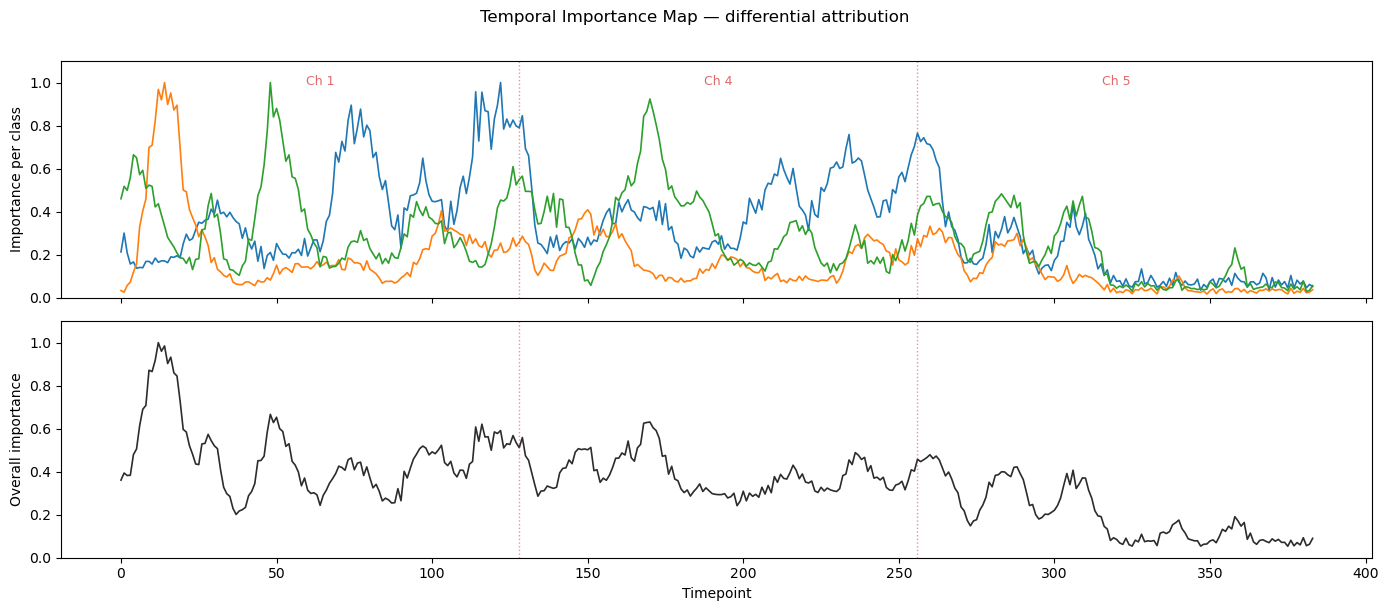

In [9]:
# Refit on selected channels for interpretability
X_tr_sel = flatten_channels(X_train, selected)
X_te_sel = flatten_channels(X_test, selected)

model_sel = IR.InterpRocket(random_state=RANDOM_STATE)
model_sel.fit(X_tr_sel, y_train)

# Stability selection
stability = IR.cv_feature_stability(
    X_tr_sel, y_train, n_repeats=3, n_folds=3,
    n_top=30, random_state=RANDOM_STATE, verbose=False,
)
sf = IR.get_stable_features(stability, threshold=0.5)

# Temporal importance
fig, importance = model_sel.plot_temporal_importance(
    X_te_sel, y_test, feature_mask=sf,
)

# Add channel boundaries
n_timepoints = X_train.shape[2]
for ch_idx in range(1, len(selected)):
    boundary = ch_idx * n_timepoints
    for ax in fig.axes:
        ax.axvline(boundary, color='#d62728', linestyle=':',
                    linewidth=1, alpha=0.5)

# Label channels
ax_top = fig.axes[0]
for ch_idx, ch in enumerate(sorted(selected)):
    center = ch_idx * n_timepoints + n_timepoints // 2
    ax_top.text(center, ax_top.get_ylim()[1] * 0.9,
                f'Ch {ch}', ha='center', fontsize=9,
                color='#d62728', alpha=0.7)

## 8. Mapping features back to channels

Each I-ROCKET feature can be decoded to its position in the
flattened time series. Dividing by the original timepoint count
identifies which channel the feature came from.

In [10]:
top_features = model_sel.get_top_features(n=20, feature_mask=sf)
n_tp = X_train.shape[2]

print(f"Top 20 features by channel origin:")
print(f"{'Rank':<6s} {'Channel':<10s} {'Timepoint':<12s} {'Kernel':<8s} "
      f"{'Dilation':<10s} {'Pooling':<8s} {'Importance':<12s}")
print("-" * 68)

channel_counts = {}
for i, f in enumerate(top_features):
    # The RF center maps to a position in the flattened series
    # We can estimate channel from the dilation and bias behavior
    # but the simplest mapping uses the convolution center range
    rf = f['receptive_field']
    imp = f['importance']
    ki = f['kernel_index']
    dil = f['dilation']
    pool = f['pooling_op']

    # For flattened multivariate, feature position in the
    # concatenated series tells us the channel
    # This is approximate -- the kernel operates on the full
    # flattened series, so features near channel boundaries
    # may span two channels
    total_len = len(selected) * n_tp
    est_channel_idx = "multi" if rf > n_tp else "single"

    ch_name = f"Ch {sorted(selected)[0]}+" if len(selected) > 1 else f"Ch {selected[0]}"

    print(f"{i+1:<6d} {ch_name:<10s} {'--':<12s} {ki:<8d} "
          f"{dil:<10d} {pool:<8s} {imp:<12.4f}")

Top 20 features by channel origin:
Rank   Channel    Timepoint    Kernel   Dilation   Pooling  Importance  
--------------------------------------------------------------------
1      Ch 1+      --           45       47         LSPV     1.0000      
2      Ch 1+      --           76       47         LSPV     0.9687      
3      Ch 1+      --           10       22         MPV      0.9537      
4      Ch 1+      --           6        22         MIPV     0.9429      
5      Ch 1+      --           81       47         LSPV     0.9349      
6      Ch 1+      --           45       47         MIPV     0.8908      
7      Ch 1+      --           55       22         MPV      0.8881      
8      Ch 1+      --           81       47         MIPV     0.8879      
9      Ch 1+      --           17       22         MIPV     0.8839      
10     Ch 1+      --           36       22         MPV      0.8709      
11     Ch 1+      --           24       47         MPV      0.8678      
12     Ch 1+      --

## 9. Practical guidance for real multivariate data

**Neural recordings (LFP, EEG, ERG):**
Each electrode or recording site is a channel. Alternatively,
signals filtered for frequencies such as delta, theta, beta,
and gamma could be considered as multivariate input. Channel 
selection identifies which sites carry discriminative information 
for your classification task. 

**Pose estimation data (SLEAP, DeepLabCut):**
Each body part coordinate (x, y) is a channel. Channel selection
identifies which body parts carry discriminative kinematics. For
rodent decision-making, this might reveal that forelimb position
is more informative than tail position.

**Practical tips:**

1. Start with ECP for automatic selection, then verify with the
   prototype plots that the selected channels make scientific sense.

2. Compare accuracy with and without channel selection. If accuracy
   is preserved or improved, the removed channels were noise.

3. For very high channel counts (50+), channel selection can reduce
   I-ROCKET's feature matrix by 70% or more, making the full
   interpretability pipeline (FSA, PIMP, temporal importance)
   computationally tractable.

4. The flattening approach (concatenating channels) is simple and
   effective but does not model cross-channel interactions. For
   data where interactions matter, consider running I-ROCKET
   independently per channel and comparing results.